In [1]:
import pandas as pd

df1 = pd.read_csv("results/results_dataset1_analysis.csv")
df2 = pd.read_csv("results/results_dataset2_analysis.csv")
df3 = pd.read_csv("results/results_dataset3_analysis.csv")

In [2]:
df1["Dataset"] = "Indoor Lab"
df2["Dataset"] = "Industrial Hall"
df3["Dataset"] = "Smart Building"

In [3]:
df1_common = df1[["ResidualScore", "Risk", "Dataset"]].copy()
df2_common = df2[["ResidualScore", "Risk", "Dataset"]].copy()
df3_common = df3[["ResidualScore", "Risk", "Dataset"]].copy()

In [4]:
df_all = pd.concat([df1_common, df2_common, df3_common], ignore_index=True)

print(df_all.head())
print(df_all["Dataset"].value_counts())

   ResidualScore      Risk     Dataset
0       0.210373  0.035063  Indoor Lab
1       0.206374  0.034390  Indoor Lab
2       0.215335  0.035899  Indoor Lab
3       0.216920  0.036166  Indoor Lab
4       0.222898  0.037172  Indoor Lab
Dataset
Industrial Hall    248442
Indoor Lab          11737
Smart Building       1976
Name: count, dtype: int64


C:\Users\Yasitha\AppData\Local\Temp\ipykernel_11028\315210191.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Indoor Lab", "Industrial Hall", "Smart Building"])


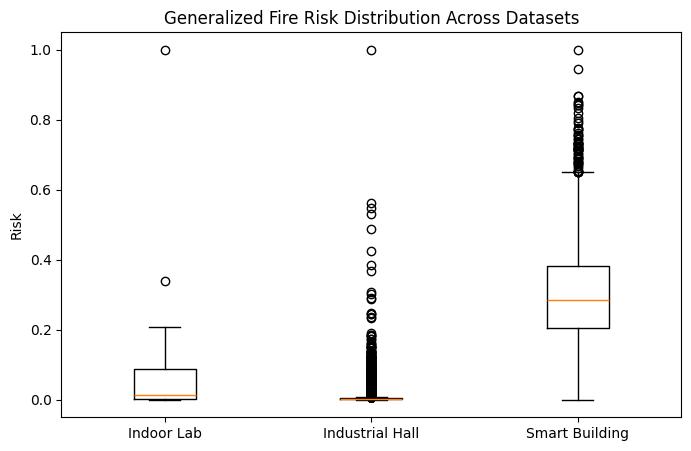

In [5]:
import matplotlib.pyplot as plt

data = [
    df_all[df_all["Dataset"] == "Indoor Lab"]["Risk"],
    df_all[df_all["Dataset"] == "Industrial Hall"]["Risk"],
    df_all[df_all["Dataset"] == "Smart Building"]["Risk"]
]

plt.figure(figsize=(8,5))
plt.boxplot(data, labels=["Indoor Lab", "Industrial Hall", "Smart Building"])
plt.ylabel("Risk")
plt.title("Generalized Fire Risk Distribution Across Datasets")
plt.show()

C:\Users\Yasitha\AppData\Local\Temp\ipykernel_11028\1684556614.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Indoor Lab", "Industrial Hall", "Smart Building"])


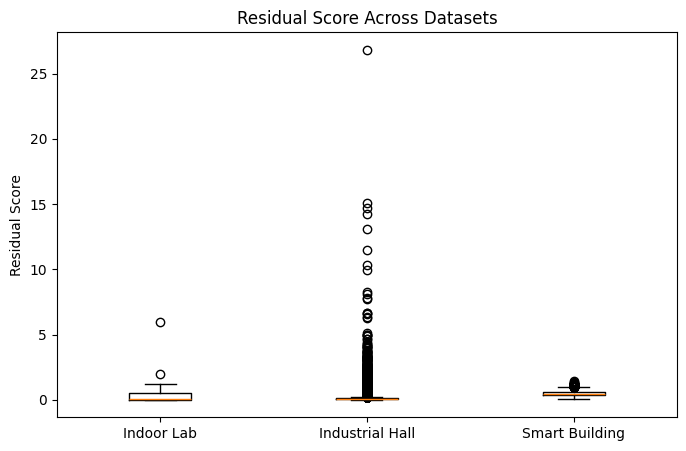

In [6]:
data = [
    df_all[df_all["Dataset"] == "Indoor Lab"]["ResidualScore"],
    df_all[df_all["Dataset"] == "Industrial Hall"]["ResidualScore"],
    df_all[df_all["Dataset"] == "Smart Building"]["ResidualScore"]
]

plt.figure(figsize=(8,5))
plt.boxplot(data, labels=["Indoor Lab", "Industrial Hall", "Smart Building"])
plt.ylabel("Residual Score")
plt.title("Residual Score Across Datasets")
plt.show()

C:\Users\Yasitha\AppData\Local\Temp\ipykernel_11028\1684556614.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Indoor Lab", "Industrial Hall", "Smart Building"])


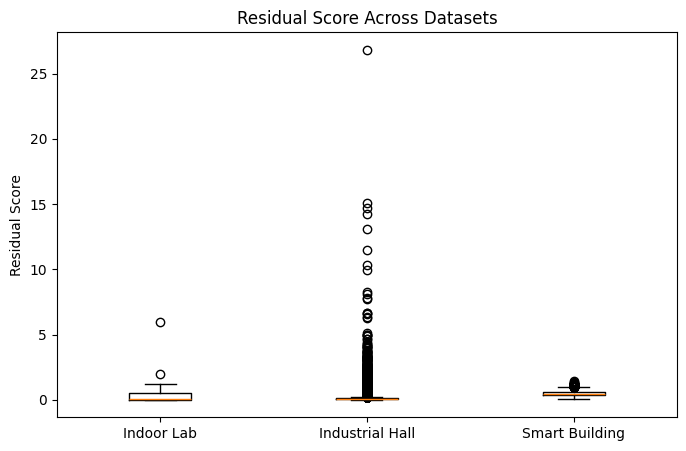

In [7]:
data = [
    df_all[df_all["Dataset"] == "Indoor Lab"]["ResidualScore"],
    df_all[df_all["Dataset"] == "Industrial Hall"]["ResidualScore"],
    df_all[df_all["Dataset"] == "Smart Building"]["ResidualScore"]
]

plt.figure(figsize=(8,5))
plt.boxplot(data, labels=["Indoor Lab", "Industrial Hall", "Smart Building"])
plt.ylabel("Residual Score")
plt.title("Residual Score Across Datasets")
plt.show()

In [10]:
summary = df_all.groupby("Dataset")[["ResidualScore","Risk"]].agg(
    ["mean","median","std","max"]
)

print(summary)

                ResidualScore                                     Risk  \
                         mean    median       std        max      mean   
Dataset                                                                  
Indoor Lab           0.263544  0.083698  0.343840   5.940999  0.044016   
Industrial Hall      0.104557  0.069311  0.154924  26.819042  0.003563   
Smart Building       0.510086  0.482508  0.198769   1.443347  0.305627   

                                          
                   median       std  max  
Dataset                                   
Indoor Lab       0.013733  0.057897  1.0  
Industrial Hall  0.002249  0.005779  1.0  
Smart Building   0.285109  0.147890  1.0  


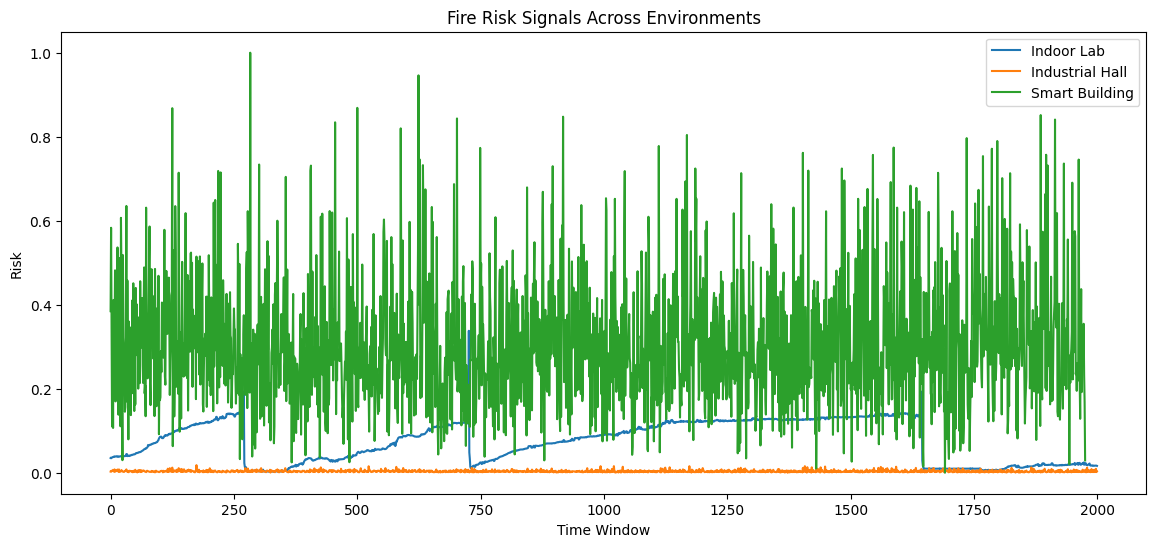

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df1["Risk"].values[:2000], label="Indoor Lab")
plt.plot(df2["Risk"].values[:2000], label="Industrial Hall")
plt.plot(df3["Risk"].values[:2000], label="Smart Building")

plt.legend()

plt.title("Fire Risk Signals Across Environments")

plt.xlabel("Time Window")
plt.ylabel("Risk")

plt.show()

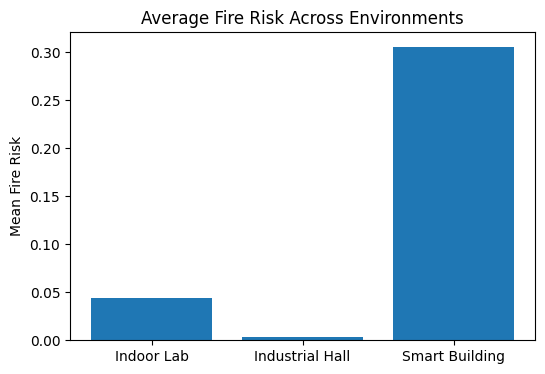

In [12]:
import matplotlib.pyplot as plt

datasets = ["Indoor Lab", "Industrial Hall", "Smart Building"]
risk_mean = [0.044016, 0.003563, 0.305627]

plt.figure(figsize=(6,4))

plt.bar(datasets, risk_mean)

plt.ylabel("Mean Fire Risk")
plt.title("Average Fire Risk Across Environments")

plt.show()